<a href="https://colab.research.google.com/github/lufergonza/t/blob/main/Teoria_de_juegos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**ALGORITMO DE BUSQUEDA A***

**ALGORITMO DE BUSQUEDA A***

se clasifica dentro de los algoritmos de búsqueda en grafos de tipo heurístico o informado. Presentado por primera vez en 1968 por Peter E. Hart, Nils J. Nilsson y Bertram Raphael, el algoritmo A* encuentra, siempre y cuando se cumplan unas determinadas condiciones, el camino de menor coste entre un nodo origen y uno objetivo.

el algoritmo A* (A-star) se utiliza principalmente para la búsqueda de rutas y el recorrido de grafos. Es famoso por su eficiencia a la hora de determinar la ruta más corta. Campos como la inteligencia artificial, la robótica y el desarrollo de juegos dependen de este algoritmo


 **IDEA PRINCIPAL DE A***

El algoritmo evalúa cada nodo usando una función:

f(n) = g(n) + h(n)

Donde:

g(n) → costo real desde el nodo inicial hasta el nodo actual.

h(n) → heurística, estimación del costo desde el nodo actual hasta el objetivo.

f(n) → costo total estimado del camino pasando por ese nodo.

El algoritmo siempre explora primero el nodo con el menor valor de f(n)

**¿COMO FUNCIONA?**

Se inicia en el nodo inicial.

Se agregan los nodos vecinos a una lista abierta (open list).

Para cada nodo se calcula:

𝑔
(
𝑛
)
g(n)

ℎ
(
𝑛
)
h(n)

𝑓
(
𝑛
)
f(n)

Se selecciona el nodo con menor f(n).

Se repite el proceso hasta llegar al nodo objetivo.

Durante el proceso se usan dos listas:

Open list → nodos por explorar

Closed list → nodos ya explorados
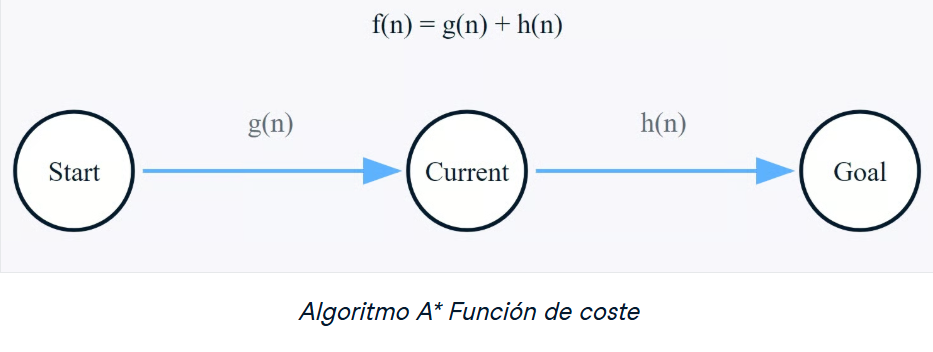




##**HEURISTICA**

   **¿QUE ES HEURISTICA ?**
   
   La programación heurística es una técnica de programación en la que se diseña un programa informático para resolver un problema tratando de encontrar una solución que se acerque lo más posible al óptimo, dentro de un conjunto determinado de restricciones. La programación heurística se utiliza a menudo en problemas de optimización, donde el objetivo es encontrar la mejor solución posible de un conjunto de soluciones potenciales.

Aplicaciones: optimización de rutas, aprendizaje automático, diseño de redes, planificación de horarios y gestión de inventarios.

Ventajas: ofrecen soluciones rápidas y cercanas a lo óptimo, escalables para grandes datos y eficientes en tiempo computacional.

Limitaciones: no garantizan la solución óptima, pueden quedar en óptimos locales y su eficacia depende de parámetros y heurísticas.


**TIPOS DE HEURISTICAS**

**Heurística Manhattan**

Es una heurística que calcula la distancia entre dos puntos en una cuadrícula sumando las diferencias en los ejes X y Y.

Se llama Manhattan porque simula las calles de una ciudad en cuadrícula, donde solo puedes moverte arriba, abajo, izquierda o derecha.

h(n) = |x_1 - x_2| + |y_1 - y_2|

**Heurística Euclidiana**

Es una heurística que calcula la distancia en línea recta entre dos puntos.

Se basa en el teorema de Pitágoras.

h(n) = \sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}


**Heurística Greedy (Voraz)**

Es una heurística donde el algoritmo elige siempre la opción que parece mejor en ese momento, sin analizar todas las combinaciones posibles.

Se llama voraz porque toma la mejor decisión inmediata.

###**EJEMPLO #1**

In [ ]:
import heapq
from typing import List, Tuple, Optional

# Tipo para coordenadas
Coord = Tuple[int, int]

def heuristic(a: Coord, b: Coord) -> float:
    """
    Heurística Manhattan: distancia en pasos horizontales y verticales.
    """
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def a_star_search(grid: List[List[int]], start: Coord, goal: Coord) -> Optional[List[Coord]]:
    """
    Implementación del algoritmo A* en una cuadrícula.
    grid: matriz con 0 = libre, 1 = obstáculo
    start: coordenada inicial (fila, columna)
    goal: coordenada objetivo (fila, columna)
    """
    rows, cols = len(grid), len(grid[0])

    # Validación de entradas
    if not (0 <= start[0] < rows and 0 <= start[1] < cols):
        raise ValueError("Posición inicial fuera de la cuadrícula.")
    if not (0 <= goal[0] < rows and 0 <= goal[1] < cols):
        raise ValueError("Posición objetivo fuera de la cuadrícula.")
    if grid[start[0]][start[1]] == 1 or grid[goal[0]][goal[1]] == 1:
        return None  # No hay camino si inicio o fin son obstáculos

    # Movimientos posibles (arriba, abajo, izquierda, derecha)
    neighbors = [(0, 1), (0, -1), (1, 0), (-1, 0)]

    # Cola de prioridad para nodos abiertos
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}  # Para reconstruir el camino
    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            # Reconstruir el camino
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]  # Invertir para ir de inicio a fin

        for dx, dy in neighbors:
            neighbor = (current[0] + dx, current[1] + dy)
            if 0 <= neighbor[0] < rows and 0 <= neighbor[1] < cols:
                if grid[neighbor[0]][neighbor[1]] == 1:
                    continue  # Obstáculo

                tentative_g = g_score[current] + 1  # Costo de moverse a vecino

                if tentative_g < g_score.get(neighbor, float('inf')):
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

    return None  # No se encontró camino

# Ejemplo de uso
if __name__ == "__main__":
    grid_map = [
        [0, 0, 0, 0, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0]
    ]

    start_point = (0, 0)
    goal_point = (4, 4)

    path = a_star_search(grid_map, start_point, goal_point)

    if path:
        print("Camino encontrado:", path)
    else:
        print("No hay camino posible.")


Camino encontrado: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]


###**EJEMPLO #1**

In [ ]:
import heapq

def manhattan_distance(a, b):
    """Calcula la distancia Manhattan entre dos puntos (x, y)."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def a_star_search(grid, start, goal):
    """
    Implementación de A* en una cuadrícula.
    grid: matriz 2D con 0 = libre, 1 = obstáculo
    start: tupla (x, y) de inicio
    goal: tupla (x, y) de destino
    """
    # Validación de entradas
    if not (0 <= start[0] < len(grid) and 0 <= start[1] < len(grid[0])):
        raise ValueError("Posición inicial fuera de la cuadrícula.")
    if not (0 <= goal[0] < len(grid) and 0 <= goal[1] < len(grid[0])):
        raise ValueError("Posición objetivo fuera de la cuadrícula.")
    if grid[start[0]][start[1]] == 1 or grid[goal[0]][goal[1]] == 1:
        raise ValueError("Inicio o meta bloqueados por un obstáculo.")

    # Movimientos posibles (arriba, abajo, izquierda, derecha)
    moves = [(1, 0), (-1, 0), (0, 1), (0, -1)]

    # Cola de prioridad (f, g, nodo, camino)
    open_list = []
    heapq.heappush(open_list, (0, 0, start, [start]))

    visited = set()

    while open_list:
        f, g, current, path = heapq.heappop(open_list)

        if current in visited:
            continue
        visited.add(current)

        # Si llegamos a la meta
        if current == goal:
            return path

        # Explorar vecinos
        for dx, dy in moves:
            neighbor = (current[0] + dx, current[1] + dy)

            if (0 <= neighbor[0] < len(grid) and
                0 <= neighbor[1] < len(grid[0]) and
                grid[neighbor[0]][neighbor[1]] == 0 and
                neighbor not in visited):

                g_new = g + 1
                h = manhattan_distance(neighbor, goal)
                f_new = g_new + h
                heapq.heappush(open_list, (f_new, g_new, neighbor, path + [neighbor]))

    return None  # No hay camino

# Ejemplo de uso
if __name__ == "__main__":
    grid = [
        [0, 0, 0, 0, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0]
    ]
    start = (0, 0)
    goal = (3, 4)

    try:
        path = a_star_search(grid, start, goal)
        if path:
            print("Camino encontrado:", path)
        else:
            print("No se encontró un camino.")
    except ValueError as e:
        print("Error:", e)


Camino encontrado: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4)]


###**EJEMPLO #2**

In [ ]:
# Mochila Fraccionada con heurísticas voraces
# Autor: Ejemplo educativo

from typing import List, Tuple

def mochila_fraccionada(pesos: List[float], valores: List[float], capacidad: float, heuristica: str) -> Tuple[float, List[Tuple[int, float]]]:
    """
    Resuelve el problema de la mochila fraccionada usando un algoritmo voraz con distintas heurísticas.

    :param pesos: Lista de pesos de los objetos
    :param valores: Lista de valores de los objetos
    :param capacidad: Capacidad máxima de la mochila
    :param heuristica: Tipo de heurística ('valor', 'peso', 'densidad')
    :return: Valor total y lista de (índice, fracción tomada)
    """
    n = len(pesos)
    if n != len(valores):
        raise ValueError("Las listas de pesos y valores deben tener la misma longitud.")
    if capacidad <= 0:
        return 0, []

    # Definir función heurística
    if heuristica == "valor":
        clave = lambda i: valores[i]  # Mayor valor primero
    elif heuristica == "peso":
        clave = lambda i: -pesos[i]   # Menor peso primero
    elif heuristica == "densidad":
        clave = lambda i: valores[i] / pesos[i]  # Mayor valor/peso primero
    else:
        raise ValueError("Heurística no válida. Use: 'valor', 'peso' o 'densidad'.")

    # Ordenar índices según la heurística
    indices = sorted(range(n), key=clave, reverse=True)

    valor_total = 0.0
    seleccion = []

    for i in indices:
        if capacidad <= 0:
            break
        if pesos[i] <= capacidad:
            # Tomar todo el objeto
            capacidad -= pesos[i]
            valor_total += valores[i]
            seleccion.append((i, 1.0))
        else:
            # Tomar fracción del objeto
            fraccion = capacidad / pesos[i]
            valor_total += valores[i] * fraccion
            seleccion.append((i, fraccion))
            capacidad = 0

    return valor_total, seleccion


# Ejemplo de uso
if __name__ == "__main__":
    pesos = [10, 20, 30]
    valores = [60, 100, 120]
    capacidad = 50

    for h in ["valor", "peso", "densidad"]:
        valor, items = mochila_fraccionada(pesos, valores, capacidad, h)
        print(f"Heurística: {h}")
        print(f"Valor total: {valor:.2f}")
        print("Objetos tomados (índice, fracción):", items)
        print("-" * 40)


Heurística: valor
Valor total: 220.00
Objetos tomados (índice, fracción): [(2, 1.0), (1, 1.0)]
----------------------------------------
Heurística: peso
Valor total: 240.00
Objetos tomados (índice, fracción): [(0, 1.0), (1, 1.0), (2, 0.6666666666666666)]
----------------------------------------
Heurística: densidad
Valor total: 240.00
Objetos tomados (índice, fracción): [(0, 1.0), (1, 1.0), (2, 0.6666666666666666)]
----------------------------------------


##**TEORIA DE JUEGOS**

¿QUE ES LA TEORIA DE JUEGOS?


La Teoría de Juegos es el estudio de modelos matemáticos que analizan las decisiones estratégicas entre varios jugadores, donde cada jugador busca maximizar su beneficio o minimizar su pérdida.

Un juego está compuesto por:

Jugadores → quienes toman decisiones

Estrategias → opciones disponibles

Pagos (payoff) → recompensa o resultado obtenido

La Teoría de juegos se divide en dos grandes ramas, Teoría de Juegos No Cooperativos y la Teoría de Juegos Cooperativos, otras divisiones del campo se caracterizan por la estructura del juego (Juegos de Suma Cero y Suma No Cero; Simétricos y Asimétricos; Estáticos y Dinámicos; Información Perfecta e Imperfecta; Información Completa e Incompleta; De un periodo, Finito o Infinitos; etc.).

**EJEMPLO CLASICO: DILEMA DEL PRISIONERO**

Dos personas son arrestadas y pueden cooperar o traicionar.

Jugador A / Jugador B	Cooperar	Traicionar

Cooperar	-1 , -1	-5 , 0

Traicionar	0 , -5	-3 , -3

Interpretación:

Si ambos cooperan, reciben una pena leve.

Si uno traiciona, sale libre y el otro recibe la peor pena.

Si ambos traicionan, ambos reciben pena media.

Este problema muestra cómo las decisiones individuales pueden llevar a resultados peores para todos.



**Equilibrio de Nash**

Es uno de los conceptos más importantes de la teoría de juegos.

Un equilibrio de Nash ocurre cuando ningún jugador puede mejorar su resultado cambiando su estrategia de manera individual.

Fue propuesto por el matemático John Nash.

Formalmente se expresa como:
En el equilibrio de Nash la estrategia que elige cada uno de los participantes de un conflicto o juego es óptima, dada la estrategia que han elegido los demás. En otras palabras, nadie ganará nada si decide cambiar su estrategia bajo el supuesto de que los demás individuos no cambian la suya.

Cabe destacar que bajo el equilibrio de Nash no necesariamente se obtiene la mayor ganancia para todos los individuos o jugadores en conjunto. Solo se cumple que cada uno responde de manera óptima ante la estrategia de los demás. En muchos casos, a los individuos les gustaría poder alcanzar otro equilibrio con mayores ganancias pero no logran hacerlo debido a que enfrentan el riesgo a ser traicionados.



In [ ]:
import random

estrategias = ["cooperar", "traicionar"]

jugadorA = random.choice(estrategias)
jugadorB = random.choice(estrategias)

print("Jugador A:", jugadorA)
print("Jugador B:", jugadorB)

if jugadorA == "cooperar" and jugadorB == "cooperar":
    print("Resultado: ambos reciben pena leve")
elif jugadorA == "traicionar" and jugadorB == "cooperar":
    print("A queda libre, B recibe pena alta")
elif jugadorA == "cooperar" and jugadorB == "traicionar":
    print("B queda libre, A recibe pena alta")
else:
    print("Ambos reciben pena media")

Jugador A: cooperar
Jugador B: cooperar
Resultado: ambos reciben pena leve


In [ ]:
import numpy as np

# matriz de pagos para jugador A
matriz = np.array([
    [3, -1],
    [2, 4]
])

print("Matriz de pagos:")
print(matriz)

Matriz de pagos:
[[ 3 -1]
 [ 2  4]]


In [ ]:
import heapq

def manhattan_distance(a, b):
    """Calcula la distancia Manhattan entre dos puntos (x, y)."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def a_star_search(grid, start, goal):
    """
    Implementación de A* en una cuadrícula.
    grid: matriz 2D con 0 = libre, 1 = obstáculo
    start: tupla (x, y) de inicio
    goal: tupla (x, y) de destino
    """
    # Validación de entradas
    if not (0 <= start[0] < len(grid) and 0 <= start[1] < len(grid[0])):
        raise ValueError("Posición inicial fuera de la cuadrícula.")
    if not (0 <= goal[0] < len(grid) and 0 <= goal[1] < len(grid[0])):
        raise ValueError("Posición objetivo fuera de la cuadrícula.")
    if grid[start[0]][start[1]] == 1 or grid[goal[0]][goal[1]] == 1:
        raise ValueError("Inicio o meta bloqueados por un obstáculo.")

    # Movimientos posibles (arriba, abajo, izquierda, derecha)
    moves = [(1, 0), (-1, 0), (0, 1), (0, -1)]

    # Cola de prioridad (f, g, nodo, camino)
    open_list = []
    heapq.heappush(open_list, (0, 0, start, [start]))

    visited = set()

    while open_list:
        f, g, current, path = heapq.heappop(open_list)

        if current in visited:
            continue
        visited.add(current)

        # Si llegamos a la meta
        if current == goal:
            return path

        # Explorar vecinos
        for dx, dy in moves:
            neighbor = (current[0] + dx, current[1] + dy)

            if (0 <= neighbor[0] < len(grid) and
                0 <= neighbor[1] < len(grid[0]) and
                grid[neighbor[0]][neighbor[1]] == 0 and
                neighbor not in visited):

                g_new = g + 1
                h = manhattan_distance(neighbor, goal)
                f_new = g_new + h
                heapq.heappush(open_list, (f_new, g_new, neighbor, path + [neighbor]))

    return None  # No hay camino

# Ejemplo de uso
if __name__ == "__main__":
    grid = [
        [0, 0, 0, 0, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0]
    ]
    start = (0, 0)
    goal = (4, 4)

    try:
        path = a_star_search(grid, start, goal)
        if path:
            print("Camino encontrado:", path)
        else:
            print("No se encontró un camino.")
    except ValueError as e:
        print("Error:", e)


Camino encontrado: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]
